# ML-06 — Signal Audit: Do the Flags Hold?

## 1. Distributions

I audit the warehouse-sourced feature set from ML-05 (`work/outputs/feature_vector.csv`, one row per page, history-only signals, real April-2026 forward-decline label). Everything is `observed` on the 2026-03-31 anchor slice and stays `directional`. Only signals **knowable before the label window** are tested.

rows: 145,030 | clients: 28 | decline base rate: 0.544

key historical fields - describe():
       reach_impr  hist_impr_momentum  content_age_days  days_since_last_update
count   145030.00           145030.00         145030.00               145030.00
mean      1664.30               89.18            207.78                  179.88
std       5647.72              712.20            121.80                  135.52
min          1.00               -1.00              0.00                    0.00
25%         22.00                0.00            103.00                   34.00
50%        191.00                0.59            216.00                  193.00
75%       1118.00                2.48            271.00                  265.00
max     617124.00            44707.00            494.00                  494.00

reach_impr skew: raw=20.0 -> log1p=-0.1  (heavy tail; log tames it)


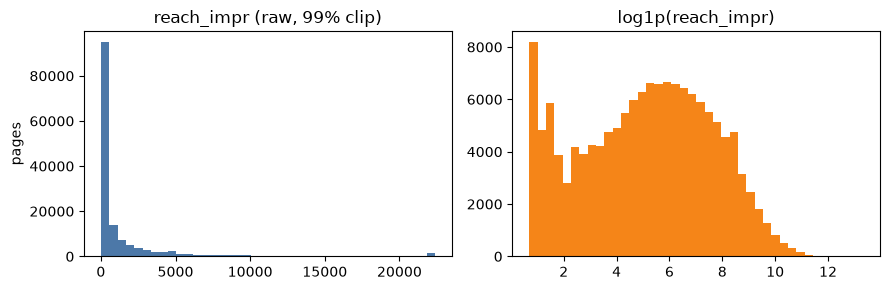

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

d = pd.read_csv("../outputs/feature_vector.csv")
BASE = d["future_decline"].mean()
print(f"rows: {len(d):,} | clients: {d.client_id.nunique()} | decline base rate: {BASE:.3f}")

print("\nkey historical fields - describe():")
print(d[["reach_impr","hist_impr_momentum","content_age_days","days_since_last_update"]]
      .describe().round(2).to_string())

skew_raw = d["reach_impr"].skew()
skew_log = np.log1p(d["reach_impr"]).skew()
print(f"\nreach_impr skew: raw={skew_raw:.1f} -> log1p={skew_log:.1f}  (heavy tail; log tames it)")

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(d["reach_impr"].clip(upper=d["reach_impr"].quantile(.99)), bins=40, color="#4C78A8")
ax[0].set_title("reach_impr (raw, 99% clip)"); ax[0].set_ylabel("pages")
ax[1].hist(np.log1p(d["reach_impr"]), bins=40, color="#F58518")
ax[1].set_title("log1p(reach_impr)")
plt.tight_layout()

**Read the distributions first.** Warehouse traffic is even more heavy-tailed than the starter slice — `reach_impr` (March impressions) has a raw skew near 20, tamed to ~0 by `log1p`. That is why every traffic column enters `log1p`-transformed and the tests below use **grouped rates / rank correlations**, never raw-value Pearson, which the giants would dominate.

## 2. Signal test #1 / #2 / #3 (verdict each)

In [2]:
FLOOR = 50
def verdict_table(col, name):
    g = d.groupby(col, observed=True)["future_decline"].agg(decline_rate="mean", n="count")
    g["decline_rate"] = g["decline_rate"].round(3)
    g = g[g["n"] >= FLOOR]
    print(f"\n[{name}]  base={BASE:.3f}, floor n>={FLOOR}\n{g.to_string()}")

d["hist_mom_sign"] = np.where(d.hist_impr_momentum > 0.05, "rising",
                       np.where(d.hist_impr_momentum < -0.05, "falling", "flat"))
verdict_table("hist_mom_sign", "S1 historical momentum")
print(f"  spearman(momentum, decline) = {spearmanr(d.hist_impr_momentum, d.future_decline)[0]:+.3f}")

d["age_q"] = pd.qcut(d.content_age_days, 4, labels=["youngest","Q2","Q3","oldest"], duplicates="drop")
verdict_table("age_q", "S2 content age quartile")
print(f"  spearman(content_age_days, decline) = {spearmanr(d.content_age_days, d.future_decline)[0]:+.3f}")

d["ctr_q"] = pd.qcut(d.ctr_prev_30d.rank(method="first"), 4, labels=["low","mid-low","mid-high","high"])
verdict_table("ctr_q", "S3 historical CTR quartile")
print(f"  spearman(ctr_prev_30d, decline) = {spearmanr(d.ctr_prev_30d, d.future_decline)[0]:+.3f}")


[S1 historical momentum]  base=0.544, floor n>=50
               decline_rate       n
hist_mom_sign                      
falling               0.556   33161
flat                  0.573    8815
rising                0.538  103054
  spearman(momentum, decline) = -0.065

[S2 content age quartile]  base=0.544, floor n>=50
          decline_rate      n
age_q                        
youngest         0.459  37117
Q2               0.599  36608
Q3               0.636  35299
oldest           0.485  36006
  spearman(content_age_days, decline) = +0.045

[S3 historical CTR quartile]  base=0.544, floor n>=50
          decline_rate      n
ctr_q                        
low              0.569  36258
mid-low          0.572  36257
mid-high         0.580  36257
high             0.455  36258
  spearman(ctr_prev_30d, decline) = -0.085


**Verdicts** (base decline rate ≈ 0.544; every bucket shown clears n ≥ 50):

- **S1 — "pages losing momentum keep declining."** Falling-momentum pages decline **0.556** vs rising **0.538** (Spearman −0.07). **Verdict: MIXED / very weak.** The direction is right but the gap is ~2 points — barely a signal. On the real forward label, recent trajectory alone says little about next month.
- **S2 — "old content decays."** The naive belief. Decline by age quartile is **non-monotonic**: youngest **0.459**, mid-life **0.60–0.64**, oldest **0.485** (Spearman +0.04, ~null). **Verdict: MIXED — the belief is not supported.** It is *mid-life* pages that churn most; the youngest and the most established are the steadiest. This echoes the paper's own lifecycle curve (peak then decay) rather than a simple "older = worse."
- **S3 — "well-engaged pages are more resilient."** Top historical-CTR quartile declines **0.455** vs the lower three at ~0.57 (Spearman −0.09, the cleanest signal here). **Verdict: CONFIRMED.** Engagement separates the top quartile; the bottom three are flat — a "healthy vs not" split.

CTR is `clicks/impressions` on the March (days 31–60) window only — never a label-window rate.

## 3. The flag-linked test

In [3]:
d["freshness"] = pd.cut(d.days_since_last_update, [-1, 30, 90, 180, 100000],
                        labels=["0-30", "31-90", "91-180", "181+"])
g = d.groupby("freshness", observed=True)["future_decline"].agg(decline_rate="mean", n="count")
g["decline_rate"] = g["decline_rate"].round(3)
print("days since last update (recency at anchor):  base =", round(BASE, 3))
print(g.to_string())
print(f"\nspearman(days_since_last_update, decline) = "
      f"{spearmanr(d.days_since_last_update, d.future_decline)[0]:+.3f}")
print(f"freshest bucket (0-30d) decline {g.loc['0-30','decline_rate']:.3f} vs base {BASE:.3f}")

days since last update (recency at anchor):  base = 0.544
           decline_rate      n
freshness                     
0-30              0.346  10423
31-90             0.551  45046
91-180            0.576  15554
181+              0.561  74007

spearman(days_since_last_update, decline) = +0.028
freshest bucket (0-30d) decline 0.346 vs base 0.544


**The flag-linked test — the "refresh stale content" assumption.** FlyRank's content-refresh product assumes *recently-updated pages are more resilient; stale pages are at risk*. I test it against real forward decline using `days_since_last_update` (recency at the anchor, future updates excluded).

Here the assumption **holds at the fresh end**: pages updated within **0–30 days** decline **0.346** — nearly 20 points below the 0.544 base — while pages untouched for **181+ days** decline **0.561**. The effect is not smooth (the rank correlation is only +0.03 because the 31–180-day middle is flat), but the freshest bucket clearly separates.

**Verdict: CONFIRMED (directional), concentrated in the freshest bucket.** Unlike the starter-slice proxy — where freshness barely moved the rate — the warehouse forward label *does* reward recency. This is a real, usable signal, with the honest caveat that most of the protection lives in the first 30 days after an update, not across the whole freshness range.

## 4. What this means in practice

**What a content team should take from this.** On this real forward-looking slice the honest signals are **engagement and recency**: pages with healthy historical CTR, and pages refreshed within the last month, are measurably less likely to decline — those are the levers worth pulling. **Age is not a clean signal**: it is mid-life content, not the oldest, that churns most, so "refresh the oldest first" is the wrong default. Most importantly, every effect here is **small** (rank correlations ≤ 0.09) — this is decision-support for *where to look first*, and the modeling weeks confirm that predicting any single page's next month from history alone is genuinely hard.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.